In [8]:
print("hello")

hello


In [9]:
import pandas as pd
import os

In [10]:
# === Setup ===
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [11]:

file_path = "general_course_data.xlsx" 
general_course_data = pd.read_excel(file_path)

In [12]:
import sys, pandas as pd
print(sys.executable)
print("pandas:", pd.__version__)

c:\Users\nguye\AppData\Local\Programs\Python\Python311\python.exe
pandas: 2.2.3


In [13]:
general_course_data

,course_url,course_slug,course_title,course_badge,skill_level,lecture_count,content_length,original_price(VNĐ),discount_price(VNĐ),num_students
0,https://www.udemy.com/course/data-science-ai-m...,data-science-ai-masters-from-python-to-gen-ai,Data Science & AI Masters 2025 - From Python T...,Bestseller,All levels,519.0,98h 14m,1239000,309000,17581
1,https://www.udemy.com/course/the-complete-ai-c...,the-complete-ai-coding-course-2025-cursor-ai-v...,"The Complete AI Coding Course (2025) - Cursor,...",Bestseller,All levels,128.0,11h 48m,409000,309000,7906
2,https://www.udemy.com/course/complete-machine-...,complete-machine-learning-nlp-bootcamp-mlops-d...,"Complete Data Science,Machine Learning,DL,NLP ...",Bestseller,All levels,429.0,99h 10m,1499000,339000,107007
3,https://www.udemy.com/course/generative-ai-for...,generative-ai-for-data-engineering,Introduction to Data Engineering using Generat...,NaN,All levels,56.0,6h 7m,799000,279000,3805
4,https://www.udemy.com/course/the-product-manag...,the-product-management-for-data-science-ai-course,The Product Management for AI & Data Science C...,Bestseller,All levels,68.0,4h 54m,2269000,479000,38826
5,https://www.udemy.com/course/generative-ai-for...,generative-ai-for-data,Generative AI for Data Engineering and Data Pr...,NaN,All levels,57.0,5h 40m,279000,399000,5283
6,https://www.udemy.com/course/the-complete-agen...,the-complete-agentic-ai-engineering-course,The Complete Agentic AI Engineering Course (2025),Bestseller,Intermediate,129.0,16h 49m,1139000,309000,121069
7,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,"The Complete AI Guide: Learn ChatGPT, Generati...",Bestseller,All levels,521.0,39h 38m,1909000,349000,306022
8,https://www.udemy.com/course/ai-automation-bui...,ai-automation-build-llm-apps-ai-agents-with-n8...,AI Automation: Build LLM Apps & AI-Agents with...,Bestseller,All levels,91.0,14h 23m,429000,319000,38324
9,https://www.udemy.com/course/n8n-course/?coupo...,n8n-course,"n8n - AI Agents, AI Automations & AI Voice Age...",Bestseller,All levels,192.0,55h 54m,889000,329000,15018


In [14]:
import glob
import os

folder_path = "data"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

In [15]:
df_list = [pd.read_csv(file) for file in csv_files]
combine_udemy_review = pd.concat(df_list, ignore_index=True)

In [16]:
combine_udemy_review

,source_file,course_url,course_slug,reviewer_name,review_text,rating_value,rating_scale,review_time_relative
0,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Avinash A.,"Fantastic course, covering all aspects of AI f...",5.0,5.0,1 week ago
1,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Gorun B.,"I loved it, Overall I would give it 4 because ...",4.0,5.0,2 weeks ago
2,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Pradeep Singh L.,An excellent course that provides valuable ins...,4.0,5.0,3 weeks ago
3,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Udemy User,There is so much information in this course. E...,5.0,5.0,3 weeks ago
4,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Eduardo A.,I can confidently say it was an awesome course...,5.0,5.0,1 month ago
...,...,...,...,...,...,...,...,...
16160,udemy_data (9).xlsx,https://www.udemy.com/course/generative-ai-for...,generative-ai-for-data-engineering,Tathagata B.,Good,5.0,5.0,1 year ago
16161,udemy_data (9).xlsx,https://www.udemy.com/course/generative-ai-for...,generative-ai-for-data-engineering,Suman V.,good,5.0,5.0,1 year ago
16162,udemy_data (9).xlsx,https://www.udemy.com/course/generative-ai-for...,generative-ai-for-data-engineering,Saurabh K.,good,5.0,5.0,1 year ago
16163,udemy_data (9).xlsx,https://www.udemy.com/course/generative-ai-for...,generative-ai-for-data-engineering,Anonymized U.,Excellent,5.0,5.0,1 year ago


In [17]:
combine_udemy_review = combine_udemy_review.applymap(lambda x: x.lower() if isinstance(x, str) else x)


C:\Users\nguye\AppData\Local\Temp\ipykernel_19900\1235387725.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combine_udemy_review = combine_udemy_review.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [18]:
import string
def remove_punctuation(text):
    if isinstance(text, str):
        return text.translate(str.maketrans('', '', string.punctuation))
    return text

In [19]:
combine_udemy_review = combine_udemy_review.applymap(remove_punctuation)


C:\Users\nguye\AppData\Local\Temp\ipykernel_19900\2272270044.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combine_udemy_review = combine_udemy_review.applymap(remove_punctuation)


In [20]:
before_dup = combine_udemy_review.shape[0]
duplicates = combine_udemy_review[combine_udemy_review.duplicated(keep=False)]
if not duplicates.empty:
    print(f"Found {duplicates.shape[0]} duplicate rows:")
    display(duplicates.head(10))  
else:
    print("No duplicates found!")

Found 128 duplicate rows:


,source_file,course_url,course_slug,reviewer_name,review_text,rating_value,rating_scale,review_time_relative
188,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,5.0,5.0,1 month ago
269,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,4.5,5.0,1 month ago
301,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,5.0,5.0,1 week ago
334,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,5.0,5.0,1 month ago
338,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,5.0,5.0,3 weeks ago
391,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,5.0,5.0,1 month ago
411,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,5.0,5.0,1 month ago
506,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,great,5.0,5.0,1 month ago
529,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,5.0,5.0,1 month ago
556,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,good,4.5,5.0,1 month ago


In [21]:
combine_udemy_review.drop_duplicates(inplace=True)
after_dup = combine_udemy_review.shape[0]
print(f"Removed {before_dup - after_dup} duplicate rows")
print(f"Final dataset shape: {combine_udemy_review.shape}")

Removed 92 duplicate rows
Final dataset shape: (16073, 8)


In [22]:
before_na = combine_udemy_review.shape[0]
missing_rows = combine_udemy_review[combine_udemy_review.isnull().any(axis=1)]
num_missing = missing_rows.shape[0]

In [23]:
if num_missing > 0:
    print(f"⚠️ Found {num_missing} rows with missing values (out of {before_na})")
    display(missing_rows.head(10))  
    
    confirm = input("Do you want to remove all missing rows? (y/n): ").strip().lower()
    if confirm == "y":
        combine_udemy_review.dropna(inplace=True)
        after_na = combine_udemy_review.shape[0]
        print(f"Removed {before_na - after_na} rows with missing values")
    else:
        print("Skipped deletion of missing rows")
else:
    print("No missing values detected!")


⚠️ Found 71 rows with missing values (out of 16073)


,source_file,course_url,course_slug,reviewer_name,review_text,rating_value,rating_scale,review_time_relative
388,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,vishvendra l,NaN,5.0,5.0,1 week ago
1254,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,NaN,5.0,5.0,9 months ago
1404,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,aashul s,NaN,5.0,5.0,9 months ago
1658,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,suneel j,NaN,4.5,5.0,2 months ago
1748,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,mahesh m,NaN,3.5,5.0,10 months ago
4500,udemydata 1xlsx,httpswwwudemycomcoursecompleteaiguidecouponcod...,completeaiguide,udemy user,NaN,4.0,5.0,1 year ago
4786,udemydata 10xlsx,httpswwwudemycomcoursetheproductmanagementford...,theproductmanagementfordatascienceaicourse,keith c b,NaN,4.0,5.0,6 months ago
5684,udemydata 10xlsx,httpswwwudemycomcoursetheproductmanagementford...,theproductmanagementfordatascienceaicourse,evan s,NaN,5.0,5.0,2 years ago
5702,udemydata 10xlsx,httpswwwudemycomcoursetheproductmanagementford...,theproductmanagementfordatascienceaicourse,william c v,NaN,2.5,5.0,2 years ago
5717,udemydata 10xlsx,httpswwwudemycomcoursetheproductmanagementford...,theproductmanagementfordatascienceaicourse,jethro r m,NaN,4.5,5.0,2 years ago


Skipped deletion of missing rows


In [24]:
combine_udemy_review.dropna(inplace=True)

In [25]:
print(combine_udemy_review.isna().sum())

source_file             0
course_url              0
course_slug             0
reviewer_name           0
review_text             0
rating_value            0
rating_scale            0
review_time_relative    0
dtype: int64


In [26]:
! pip install -r requirements.txt

  Using cached accelerate-1.10.1-py3-none-any.whl (374 kB)
  Using cached certifi-2025.10.5-py3-none-any.whl (163 kB)
                                              0.0/107.1 kB ? eta -:--:--
     ---------------------------------       92.2/107.1 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 107.1/107.1 kB 1.5 MB/s eta 0:00:00
  Using cached filelock-3.19.1-py3-none-any.whl (15 kB)
  Using cached fsspec-2025.9.0-py3-none-any.whl (199 kB)
  Using cached huggingface_hub-0.35.3-py3-none-any.whl (564 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
                                              0.0/2.0 MB ? eta -:--:--
     --                                       0.1/2.0 MB 7.5 MB/s eta 0:00:01
     -----                                    0.3/2.0 MB 4.5 MB/s eta 0:00:01
     ---------                                0.5/2.0 MB 3.8 MB/s eta 0:00:01
     

Reason for being yanked: Error in the setup causing installation issues
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\nguye\\AppData\\Roaming\\Python\\Python311\\site-packages\\~sutil\\_psutil_windows.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
! python -m spacy download en_core_web_sm

                                              0.0/12.8 MB ? eta -:--:--
                                              0.0/12.8 MB ? eta -:--:--
                                              0.1/12.8 MB 1.3 MB/s eta 0:00:10
                                              0.2/12.8 MB 2.3 MB/s eta 0:00:06
     -                                        0.4/12.8 MB 2.4 MB/s eta 0:00:06
     --                                       0.7/12.8 MB 2.9 MB/s eta 0:00:05
     --                                       0.9/12.8 MB 3.4 MB/s eta 0:00:04
     ---                                      1.1/12.8 MB 3.6 MB/s eta 0:00:04
     ----                                     1.4/12.8 MB 3.8 MB/s eta 0:00:03
     -----                                    1.6/12.8 MB 4.0 MB/s eta 0:00:03
     -----                                    1.9/12.8 MB 4.1 MB/s eta 0:00:03
     ------                                   2.1/12.8 MB 4.2 MB/s eta 0:00:03
     -------                                  2.4/12.8 MB 4.3 MB/s


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import sys, spacy
print("Kernel Python  :", sys.executable)
print("spaCy location :", spacy.__file__)

Kernel Python  : c:\Users\nguye\AppData\Local\Programs\Python\Python311\python.exe
spaCy location : c:\Users\nguye\AppData\Local\Programs\Python\Python311\Lib\site-packages\spacy\__init__.py


In [30]:
import spacy

# Load model vừa cài
nlp = spacy.load("en_core_web_sm")

# Test câu sample
doc = nlp("SpaCy is now working perfectly. You are unstoppable!")

for token in doc:
    print(f"{token.text:<12} | {token.lemma_:<12} | {token.pos_:<10} | {token.dep_:<10}")


SpaCy        | SpaCy        | PROPN      | nsubj     
is           | be           | AUX        | aux       
now          | now          | ADV        | advmod    
working      | work         | VERB       | ROOT      
perfectly    | perfectly    | ADV        | advmod    
.            | .            | PUNCT      | punct     
You          | you          | PRON       | nsubj     
are          | be           | AUX        | ROOT      
unstoppable  | unstoppable  | ADJ        | acomp     
!            | !            | PUNCT      | punct     


In [32]:
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Download NLTK resources (run once)
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Sample text
text = "The Udemy course was really helpful, but sometimes it felt too basic."

# spaCy pipeline
doc = nlp(text)

# Tokenization + POS tagging
for token in doc:
    print(f"{token.text:<12} POS={token.pos_:<10} Lemma={token.lemma_:<12}")

# Stopword removal
stop_words = set(stopwords.words("english"))
tokens_no_stop = [token.text.lower() for token in doc if token.text.lower() not in stop_words and token.is_alpha]

# Stemming
stemmer = PorterStemmer()
stems = [stemmer.stem(t) for t in tokens_no_stop]

# Lemmatization (spaCy already did it, but here’s nltk version)
lemmatizer = WordNetLemmatizer()
lemmas = [lemmatizer.lemmatize(t) for t in tokens_no_stop]

print("\Tokens:", tokens_no_stop)
print("Stems:", stems)
print("Lemmas:", lemmas)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...


The          POS=DET        Lemma=the         
Udemy        POS=PROPN      Lemma=Udemy       
course       POS=NOUN       Lemma=course      
was          POS=AUX        Lemma=be          
really       POS=ADV        Lemma=really      
helpful      POS=ADJ        Lemma=helpful     
,            POS=PUNCT      Lemma=,           
but          POS=CCONJ      Lemma=but         
sometimes    POS=ADV        Lemma=sometimes   
it           POS=PRON       Lemma=it          
felt         POS=VERB       Lemma=feel        
too          POS=ADV        Lemma=too         
basic        POS=ADJ        Lemma=basic       
.            POS=PUNCT      Lemma=.           
\Tokens: ['udemy', 'course', 'really', 'helpful', 'sometimes', 'felt', 'basic']
Stems: ['udemi', 'cours', 'realli', 'help', 'sometim', 'felt', 'basic']
Lemmas: ['udemy', 'course', 'really', 'helpful', 'sometimes', 'felt', 'basic']


In [33]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Example
text = "The course was amazing, but the instructor was too fast sometimes."

score = sia.polarity_scores(text)
print(score)


{'neg': 0.0, 'neu': 0.806, 'pos': 0.194, 'compound': 0.34}


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...


In [34]:
import pandas as pd
from tqdm import tqdm

tqdm.pandas()
combine_udemy_review["vader_score"] = combine_udemy_review["review_text"].progress_apply(lambda x: sia.polarity_scores(str(x))["compound"])

# classify sentiment
combine_udemy_review["sentiment"] = combine_udemy_review["vader_score"].apply(
    lambda x: "positive" if x > 0.05 else ("negative" if x < -0.05 else "neutral")
)

combine_udemy_review[["review_text", "vader_score", "sentiment"]].head()

  0%|          | 0/16002 [00:00<?, ?it/s]

100%|██████████| 16002/16002 [00:02<00:00, 7594.22it/s]


,review_text,vader_score,sentiment
0,fantastic course covering all aspects of ai fr...,0.7778,positive
1,i loved it overall i would give it 4 because s...,0.4588,positive
2,an excellent course that provides valuable ins...,0.7783,positive
3,there is so much information in this course ev...,0.0000,neutral
4,i can confidently say it was an awesome course...,0.8020,positive


In [35]:
combine_udemy_review[["review_text", "vader_score", "sentiment"]]

,review_text,vader_score,sentiment
0,fantastic course covering all aspects of ai fr...,0.7778,positive
1,i loved it overall i would give it 4 because s...,0.4588,positive
2,an excellent course that provides valuable ins...,0.7783,positive
3,there is so much information in this course ev...,0.0000,neutral
4,i can confidently say it was an awesome course...,0.8020,positive
...,...,...,...
16160,good,0.4404,positive
16161,good,0.4404,positive
16162,good,0.4404,positive
16163,excellent,0.5719,positive


In [36]:
combine_udemy_review[[ "sentiment"]]

,sentiment
0,positive
1,positive
2,positive
3,neutral
4,positive
...,...
16160,positive
16161,positive
16162,positive
16163,positive


In [37]:
import pandas as pd
import numpy as np
import spacy
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer


In [38]:
nltk.download("stopwords")
nltk.download("vader_lexicon")

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
sia = SentimentIntensityAnalyzer()
tqdm.pandas()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [39]:
def preprocess_spacy(text: str):
    doc = nlp(str(text))

    tokens = []
    pos_tags = []

    for tok in doc:
        if tok.is_space or tok.is_punct or tok.like_num:
            continue
        t = tok.lemma_.lower().strip()  

        if t and t not in stop_words:
            tokens.append(t)
            pos_tags.append(tok.pos_)
    return tokens, pos_tags


In [40]:
df = combine_udemy_review.copy()

df[["tokens","pos"]] = df["review_text"].progress_apply(
    lambda x: pd.Series(preprocess_spacy(x))
)

df["clean_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

df["vader_score"] = df["review_text"].progress_apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

def to_label(c):
    return "positive" if c > 0.05 else ("negative" if c < -0.05 else "neutral")

df["sentiment"] = df["vader_score"].apply(to_label)

df[["review_text","clean_text","vader_score","sentiment"]].head()


100%|██████████| 16002/16002 [00:01<00:00, 8613.00it/s]


,review_text,clean_text,vader_score,sentiment
0,fantastic course covering all aspects of ai fr...,fantastic course cover aspect ai basic expert ...,0.7778,positive
1,i loved it overall i would give it 4 because s...,love overall would give stuff overly keep repe...,0.4588,positive
2,an excellent course that provides valuable ins...,excellent course provide valuable insight ai t...,0.7783,positive
3,there is so much information in this course ev...,much information course even though lengthy fe...,0.0000,neutral
4,i can confidently say it was an awesome course...,confidently say awesome course introduce wide ...,0.8020,positive


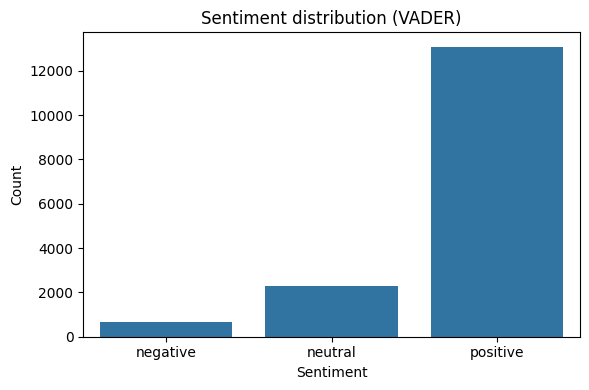

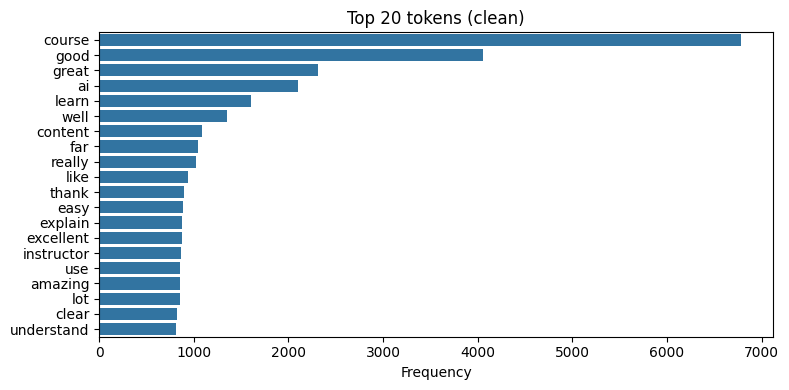

In [41]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="sentiment", order=["negative","neutral","positive"])
ax.set_title("Sentiment distribution (VADER)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

from collections import Counter
token_counts = Counter([t for toks in df["tokens"] for t in toks])
top20 = pd.DataFrame(token_counts.most_common(20), columns=["token","freq"])

plt.figure(figsize=(8,4))
ax = sns.barplot(data=top20, x="freq", y="token")
ax.set_title("Top 20 tokens (clean)")
ax.set_xlabel("Frequency")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


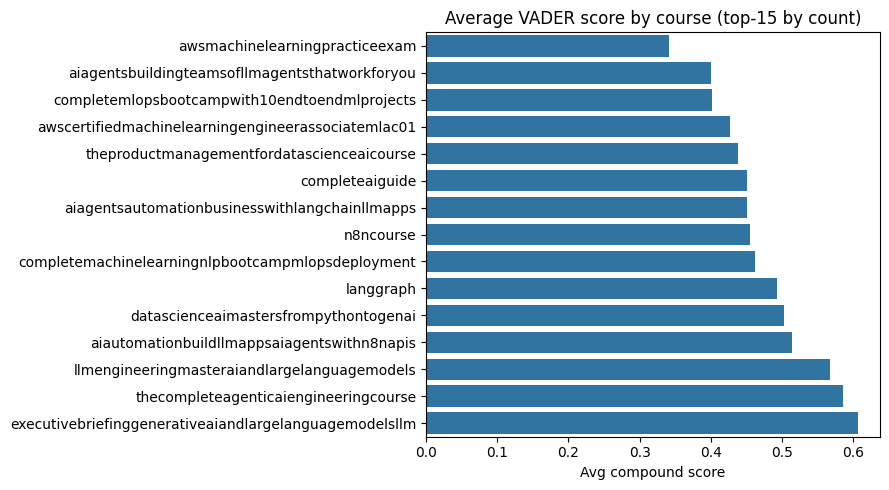

In [42]:
top_courses = df["course_slug"].value_counts().head(15).index
tmp = df[df["course_slug"].isin(top_courses)]

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=tmp.groupby("course_slug", as_index=False)["vader_score"].mean()
            .sort_values("vader_score"),
    x="vader_score", y="course_slug"
)
ax.set_title("Average VADER score by course (top-15 by count)")
ax.set_xlabel("Avg compound score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 2.4 Feature Engineering.

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

import re
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")   # 🔹 chỉ thêm dòng này

stop_words = set(stopwords.words("english"))

def tokenize(text):
    text = text.lower()
    tokens = TOKEN_RE.findall(text)
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

tfidf = TfidfVectorizer(
    tokenizer=tokenize,
    preprocessor=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=3, max_df=0.9,
    sublinear_tf=True, norm='l2'
)


In [49]:
X_tfidf = tfidf.fit_transform(df['review_text'].astype(str))
print("TF-IDF shape:", X_tfidf.shape, "| nnz:", X_tfidf.nnz)

terms = np.array(tfidf.get_feature_names_out())
scores = np.asarray(X_tfidf.sum(axis=0)).ravel()
top20 = scores.argsort()[::-1][:20]
pd.DataFrame({"term": terms[top20], "score": scores[top20]})


c:\Users\nguye\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF shape: (16002, 9289) | nnz: 164364


,term,score
0,good,1406.720951
1,course,632.235248
2,great,564.322762
3,excellent,281.230150
4,amazing,266.175218
5,nice,261.495355
6,far,249.663032
7,yes,228.574452
8,ai,221.470108
9,content,196.375023


In [51]:
# ==== 2.4.2 spaCy embeddings (300d) ====
import spacy, numpy as np
from pathlib import Path

OUT_DIR = Path("outputs/feature_engineering"); (OUT_DIR/"w2v").mkdir(parents=True, exist_ok=True)

nlp_md = spacy.load("en_core_web_md")  # có vectors 300 chiều
texts = df['review_text'].astype(str).tolist()

# embed: trung bình vector token theo spaCy
emb_spacy = np.vstack([nlp_md(t).vector for t in texts])

np.save(OUT_DIR/"w2v/doc_embeddings.npy", emb_spacy)
print("spaCy embeddings shape:", emb_spacy.shape)  # (n_samples, 300)
with open(OUT_DIR/"w2v/model_name.txt","w",encoding="utf-8") as f:
    f.write("en_core_web_md")


spaCy embeddings shape: (16002, 300)


In [52]:
# preview 5 dòng × 20 term phổ biến
import pandas as pd, numpy as np
terms = np.array(tfidf.get_feature_names_out())
scores = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_cols = scores.argsort()[::-1][:20]
mat = X_tfidf[:5, top_cols].toarray()
pd.DataFrame(mat, columns=terms[top_cols]).rename(index=lambda i: f"comment_{i+1}")


,good,course,great,excellent,amazing,nice,far,yes,ai,content,great course,well,awesome,learning,really,easy,clear,informative,good course,explanation
comment_1,0.089673,0.075007,0.0,0.000000,0.0,0.0,0.0,0.0,0.114532,0.0,0.0,0.0,0.000000,0.0,0.134871,0.0,0.0,0.0,0.0,0.0
comment_2,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
comment_3,0.000000,0.098378,0.0,0.181212,0.0,0.0,0.0,0.0,0.150217,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
comment_4,0.000000,0.063629,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
comment_5,0.000000,0.063946,0.0,0.000000,0.0,0.0,0.0,0.0,0.165322,0.0,0.0,0.0,0.142457,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [53]:
# === 0) Imports & setup ===
import re, os, numpy as np, pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import joblib

# YÊU CẦU: df phải có cột 'review_text'
assert 'df' in globals(), "Bạn cần có biến df (DataFrame) trước khi chạy."
assert 'review_text' in df.columns, "Thiếu cột 'review_text' trong df."

OUT_DIR = Path("outputs/feature_engineering"); (OUT_DIR/"w2v").mkdir(parents=True, exist_ok=True)

# Bật/tắt embeddings (mặc định tắt cho nhanh)
DO_BERT  = False
DO_SPACY = False

# === 1) Stopwords: giữ từ phủ định + thêm stoplist domain ===
# (nếu môi trường mới, có thể cần: import nltk; nltk.download('stopwords'))
try:
    from nltk.corpus import stopwords as nltk_sw
    base_sw = set(nltk_sw.words("english"))
except Exception:
    # fallback nếu NLTK chưa sẵn
    base_sw = set(ENGLISH_STOP_WORDS)

NEG_KEEP = {"not", "no", "nor", "never", "n't"}  # giữ phủ định
stop_words = base_sw - NEG_KEEP

# Stoplist theo domain Udemy/courses để đỡ nhiễu
DOMAIN_STOPS = {
    "course","courses","udemy","lecture","lectures","instructor","instructors",
    "section","sections","content","video","videos","lesson","lessons","module","modules",
    "rating","ratings","student","students","learn","learning","tutorial","tutorials"
}
stop_words |= DOMAIN_STOPS

# === 2) Tokenizer chuẩn: giữ chữ + số + contraction (don't, isn't, ...), lowercase trước ===
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")

def tokenize(text: str):
    text = text.lower()
    toks = TOKEN_RE.findall(text)
    # lọc stopwords + bỏ token quá ngắn
    return [t for t in toks if t not in stop_words and len(t) > 1]

# === 3) TF-IDF cấu hình sạch ===
tfidf = TfidfVectorizer(
    tokenizer=tokenize,
    preprocessor=None,
    lowercase=False,      # đã lowercase trong tokenizer
    ngram_range=(1, 2),   # giữ bigram để bắt "not good", "not worth", ...
    min_df=5,             # loại từ quá hiếm (tùy dữ liệu, có thể 3-10)
    max_df=0.7,           # loại từ quá phổ biến
    sublinear_tf=True,    # log(1+tf)
    norm='l2',            # chuẩn hóa từng doc
    dtype=np.float32
)

texts = df['review_text'].astype(str).tolist()
X_tfidf = tfidf.fit_transform(texts)
terms = np.array(tfidf.get_feature_names_out())

print(f"TF-IDF shape: {X_tfidf.shape} | nnz: {X_tfidf.nnz}")

# === 4) Scoring term đúng bản chất: mean TF-IDF + DF (doc frequency) ===
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()  # trung bình theo doc
dfreq      = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()  # số doc có chứa term

topN = 30
top_idx = mean_tfidf.argsort()[::-1][:topN]
top_terms_df = pd.DataFrame({
    "term": terms[top_idx],
    "mean_tfidf": mean_tfidf[top_idx],
    "doc_freq": dfreq[top_idx].astype(int)
})

print("\n=== Top terms (by mean TF-IDF) ===")
print(top_terms_df.head(20))

# Lưu artefacts để tái dùng
joblib.dump(tfidf, OUT_DIR/"w2v/tfidf_vectorizer.joblib")
top_terms_df.to_csv(OUT_DIR/"w2v/top_terms_mean_tfidf.csv", index=False)

# === 5) Preview “đẹp” hơn: top-k term theo TỪNG comment (ít ô = 0) ===
def top_terms_per_doc(X, terms, row, k=10):
    rowv = X[row].toarray().ravel()
    idx = np.argsort(rowv)[::-1][:k]
    return [(terms[i], float(rowv[i])) for i in idx if rowv[i] > 0]

print("\n=== Top 10 terms per doc (5 docs đầu) ===")
n_show = min(5, X_tfidf.shape[0])
for i in range(n_show):
    print(f"- comment_{i+1}:", top_terms_per_doc(X_tfidf, terms, row=i, k=10))

# === 6) OPTIONAL: Heatmap-like preview (5 docs × 20 global terms) để so sánh ===
# Lưu ý: nhiều 0 là bình thường vì không phải doc nào cũng chứa các term global top.
global_top = top_idx[:20]
mat = X_tfidf[:n_show, :][:, global_top].toarray()
preview_df = pd.DataFrame(mat, columns=terms[global_top]).rename(index=lambda i: f"comment_{i+1}")
preview_df.to_csv(OUT_DIR/"w2v/preview_5x20.csv")
print("\nSaved 5x20 preview to:", OUT_DIR/"w2v/preview_5x20.csv")

# === 7) OPTIONAL: Embeddings (đổi tên file để KHÔNG ghi đè giữa BERT và spaCy) ===
if DO_BERT:
    from sentence_transformers import SentenceTransformer
    model_bert = SentenceTransformer("all-MiniLM-L6-v2")
    emb_bert = model_bert.encode(texts, convert_to_numpy=True, show_progress_bar=True, normalize_embeddings=True)
    np.save(OUT_DIR/"w2v/doc_embeddings_bert.npy", emb_bert)
    with open(OUT_DIR/"w2v/model_name_bert.txt","w",encoding="utf-8") as f:
        f.write("all-MiniLM-L6-v2")
    print("BERT embeddings:", emb_bert.shape)

if DO_SPACY:
    import spacy
    nlp_md = spacy.load("en_core_web_md")  # 300d
    emb_spacy = np.vstack([nlp_md(t).vector for t in texts])
    np.save(OUT_DIR/"w2v/doc_embeddings_spacy.npy", emb_spacy)
    with open(OUT_DIR/"w2v/model_name_spacy.txt","w",encoding="utf-8") as f:
        f.write("en_core_web_md")
    print("spaCy embeddings:", emb_spacy.shape)

print("\nDONE: FE xong. Dùng top_terms_mean_tfidf.csv + preview_5x20.csv để kiểm tra nhanh.")


c:\Users\nguye\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF shape: (16002, 4483) | nnz: 131259

=== Top terms (by mean TF-IDF) ===
           term  mean_tfidf  doc_freq
0          good    0.097835      3397
1         great    0.043390      2171
2     excellent    0.020871       855
3       amazing    0.020032       826
4          nice    0.018905       516
5           far    0.017425       980
6            ai    0.016066      1675
7           yes    0.015072       466
8       awesome    0.012658       375
9          well    0.012506       917
10       really    0.012281       939
11         easy    0.011535       817
12        clear    0.011408       774
13  informative    0.011271       418
14          not    0.010869       910
15         best    0.010240       593
16         like    0.009825       770
17   understand    0.009644       704
18  explanation    0.009361       484
19          lot    0.009152       675

=== Top 10 terms per doc (5 docs đầu) ===
- comment_1: [('aspects ai', 0.3511011600494385), ('analysis', 0.3232391178607940

In [54]:
# ============================================
# PART 3++ : TF-IDF + Logistic Regression (tuned, CV, calibrated)
# ============================================

import os, re, warnings, math
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold, GridSearchCV, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

# --------- 0) DATAFRAME COMBINED ----------
if 'combine_udemy_review' not in globals() and 'combine_udemy_review' not in locals():
    raise RuntimeError("Không thấy biến 'combine_udemy_review'. Chạy cell combine trước nha.")
df = combine_udemy_review.copy()
df.columns = [str(c) for c in df.columns]

# detect columns
TEXT_COL = None
for c in df.columns:
    lc = c.lower()
    if "review" in lc and "text" in lc: TEXT_COL = c; break
if TEXT_COL is None: raise KeyError("Không tìm thấy cột text (vd: review_text).")
df[TEXT_COL] = df[TEXT_COL].astype(str)

RATING_COL = None
for c in ["rating_value","rating_val","rating","stars","rating_val_num","rating_value_num"]:
    if c in df.columns: RATING_COL = c; break

# --------- 1) LABELS (VADER ưu tiên, fallback rating) ----------
def to_label(c, pos_th=0.05, neg_th=-0.05):
    if c > pos_th: return "positive"
    if c < neg_th: return "negative"
    return "neutral"

vader_col = None
if "vader_score" in df.columns:
    vader_col = "vader_score"
else:
    # tính VADER nếu có thể
    try:
        import nltk
        from nltk.sentiment import SentimentIntensityAnalyzer
        try:
            _ = nltk.data.find("sentiment/vader_lexicon.zip")
        except LookupError:
            nltk.download("vader_lexicon")
        sia = SentimentIntensityAnalyzer()
        df["vader_score"] = df[TEXT_COL].map(lambda x: sia.polarity_scores(x)["compound"])
        vader_col = "vader_score"
        print("[i] Đã tính vader_score (VADER).")
    except Exception as e:
        print(f"[!] Không tính được VADER ({e}) → fallback rating.")

if vader_col is not None:
    df["label"] = df[vader_col].apply(to_label)
else:
    if RATING_COL is None:
        raise RuntimeError("Không có 'vader_score' cũng không có cột rating để map label.")
    def map_from_rating(r):
        try: r = float(r)
        except: return "neutral"
        if r <= 2: return "negative"
        if r >= 4: return "positive"
        return "neutral"
    df["label"] = df[RATING_COL].apply(map_from_rating)

print("\n[i] Label distribution:")
print(df["label"].value_counts())

# --------- 2) TOKENIZERS (with vs without negation for ablation) ----------
# stopwords robust
try:
    from nltk.corpus import stopwords as nltk_sw
    try:
        base_sw = set(nltk_sw.words("english"))
    except LookupError:
        import nltk
        nltk.download("stopwords")
        base_sw = set(nltk_sw.words("english"))
except Exception:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    base_sw = set(ENGLISH_STOP_WORDS)

NEG_KEEP = {"not","no","nor","never","n't"}
DOMAIN_STOPS = {
    "course","courses","udemy","lecture","lectures","instructor","instructors",
    "section","sections","content","video","videos","lesson","lessons",
    "module","modules","rating","ratings","student","students","tutorial","tutorials"
}
STOP_keepNeg = (base_sw - NEG_KEEP) | DOMAIN_STOPS
STOP_dropNeg = base_sw | DOMAIN_STOPS   # ablation: không giữ negation
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")

def tokenize_keep_neg(text: str):
    toks = TOKEN_RE.findall(str(text).lower())
    return [t for t in toks if t not in STOP_keepNeg and len(t) > 1]

def tokenize_drop_neg(text: str):
    toks = TOKEN_RE.findall(str(text).lower())
    return [t for t in toks if t not in STOP_dropNeg and len(t) > 1]

# --------- 3) SPLIT ----------
X = df[TEXT_COL].astype(str).values
y = df["label"].values
groups = df["course_url"].values if "course_url" in df.columns else None  # dùng cho GroupKFold nếu có

try:
    Xtr, Xte, ytr, yte, gtr, gte = train_test_split(
        X, y, groups, test_size=0.2, stratify=y, random_state=42
    )
except ValueError:
    Xtr, Xte, ytr, yte, gtr, gte = train_test_split(
        X, y, groups, test_size=0.2, random_state=42
    )

# --------- 4) PIPELINE + GRID SEARCH (CV) ----------
# chọn tokenizer giữ negation cho mốc "model chính"
tfidf = TfidfVectorizer(
    tokenizer=tokenize_keep_neg,
    preprocessor=None,
    lowercase=False,
    analyzer="word",
    token_pattern=None,
)

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

pipe = Pipeline([
    ("tfidf", tfidf),
    ("clf", logreg)
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [3,5],
    "tfidf__max_df": [0.7, 0.9],
    "clf__C": [0.5, 1.0, 2.0],
}

cv = GroupKFold(n_splits=5) if gtr is not None else StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv.split(Xtr, ytr, groups=gtr) if gtr is not None else cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)
gs.fit(Xtr, ytr)

print("\n[i] Best params:", gs.best_params_)
print("[i] Best CV macro-F1: {:.3f}".format(gs.best_score_))

best_model = gs.best_estimator_

# --------- 5) CALIBRATION (optional but nice) ----------
cal = CalibratedClassifierCV(best_model["clf"], method="isotonic", cv=3)
# Fit calibration using transformed features from best tfidf
Xtr_t = best_model["tfidf"].fit_transform(Xtr)  # ensure fitted
cal.fit(Xtr_t, ytr)
# For test, we need to reuse the same tfidf
Xte_t = best_model["tfidf"].transform(Xte)

y_pred = best_model.predict(Xte)
y_proba = cal.predict_proba(Xte_t)

report = classification_report(yte, y_pred, digits=3)
cm = confusion_matrix(yte, y_pred, labels=best_model["clf"].classes_)
labels_order = list(best_model["clf"].classes_)

print("\n=== TEST REPORT (best tuned) ===")
print(report)
print("Confusion matrix:\n", cm)

os.makedirs("artifacts", exist_ok=True)
with open("artifacts/classification_report_tuned.txt","w",encoding="utf-8") as f:
    f.write("[Best params] " + str(gs.best_params_) + "\n")
    f.write("[Best CV macro-F1] {:.3f}\n\n".format(gs.best_score_))
    f.write(report + "\nConfusion matrix:\n" + np.array2string(cm))

# --------- 6) CM chuẩn hóa & plot learning curve ----------
# CM normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(5,4))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Normalized Confusion Matrix (tuned)")
plt.colorbar()
tick_idx = np.arange(len(labels_order))
plt.xticks(tick_idx, labels_order, rotation=45)
plt.yticks(tick_idx, labels_order)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                 color="white" if cm_norm[i,j] > 0.5 else "black")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix_norm_tuned.png", dpi=200)
plt.close()

# Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_model, Xtr, ytr,
    cv=cv.split(Xtr, ytr, groups=gtr) if gtr is not None else cv,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True, random_state=42
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(5,4))
plt.plot(train_sizes, train_mean, marker="o", label="Train F1 (macro)")
plt.plot(train_sizes, test_mean, marker="o", label="CV F1 (macro)")
plt.xlabel("Training samples")
plt.ylabel("F1 (macro)")
plt.title("Learning Curve (tuned TF-IDF + LR)")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/learning_curve_tuned.png", dpi=200)
plt.close()
print("[i] Saved CM & learning curve PNG.")

# --------- 7) Top n-grams mỗi lớp (từ model tuned) ----------
tfidf_best = best_model["tfidf"]
clf_best = best_model["clf"]
feats = np.array(tfidf_best.get_feature_names_out())
tops = {}
for i, cls in enumerate(clf_best.classes_):
    idx = np.argsort(clf_best.coef_[i])[::-1][:20]
    tops[cls] = list(zip(feats[idx], clf_best.coef_[i][idx]))

with open("artifacts/top_ngrams_tuned.txt","w",encoding="utf-8") as f:
    for cls, pairs in tops.items():
        f.write(f"\n[{cls}]\n")
        for w, c in pairs:
            f.write(f"{w:30s} {float(c):+.4f}\n")
print("[i] Saved artifacts/top_ngrams_tuned.txt")

# --------- 8) Error analysis: misclassified + confidence ----------
proba_map = {c:i for i,c in enumerate(clf_best.classes_)}
# prob của class dự đoán
y_pred_idx = [proba_map[c] for c in y_pred]
conf = y_proba[np.arange(len(y_pred)), y_pred_idx]
err_mask = (y_pred != yte)
err_df = pd.DataFrame({
    "text": Xte,
    "true": yte,
    "pred": y_pred,
    "conf_pred": conf
})
err_df = err_df[err_mask].sort_values("conf_pred", ascending=False)
err_df.head(50).to_csv("artifacts/top_confident_errors.csv", index=False, encoding="utf-8")
print("[i] Saved artifacts/top_confident_errors.csv (50 lỗi tự tin nhất)")

# --------- 9) Ablation: BỎ giữ negation để so sánh nhanh ----------
pipe_ablate = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenize_drop_neg,
        preprocessor=None,
        lowercase=False,
        analyzer="word",
        token_pattern=None
    )),
    ("clf", LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="liblinear", random_state=42
    ))
])
pipe_ablate.set_params(
    tfidf__ngram_range=gs.best_params_.get("tfidf__ngram_range",(1,2)),
    tfidf__min_df=gs.best_params_.get("tfidf__min_df",5),
    tfidf__max_df=gs.best_params_.get("tfidf__max_df",0.7),
    clf__C=gs.best_params_.get("clf__C",1.0)
)
pipe_ablate.fit(Xtr, ytr)
y_pred_ab = pipe_ablate.predict(Xte)
f1_ab = f1_score(yte, y_pred_ab, average="macro")
f1_main = f1_score(yte, y_pred, average="macro")
print("\n=== Ablation (drop negation words) ===")
print("Macro-F1 (main, keep neg): {:.3f} | Macro-F1 (ablate, drop neg): {:.3f}".format(f1_main, f1_ab))
with open("artifacts/ablation.txt","w",encoding="utf-8") as f:
    f.write("Macro-F1 (main, keep neg): {:.3f}\n".format(f1_main))
    f.write("Macro-F1 (ablate, drop neg): {:.3f}\n".format(f1_ab))

# --------- 10) SAVE final estimator (tfidf + clf tuned) ----------
from joblib import dump
os.makedirs("artifacts", exist_ok=True)
dump(tfidf_best, "artifacts/tfidf_tuned.joblib")
dump(clf_best,   "artifacts/logreg_tuned.joblib")
print("[i] Saved tuned artifacts: artifacts/tfidf_tuned.joblib & artifacts/logreg_tuned.joblib")



[i] Label distribution:
label
positive    13083
neutral      2272
negative      647
Name: count, dtype: int64
Fitting 5 folds for each of 24 candidates, totalling 120 fits

[i] Best params: {'clf__C': 2.0, 'tfidf__max_df': 0.7, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
[i] Best CV macro-F1: 0.768

=== TEST REPORT (best tuned) ===
              precision    recall  f1-score   support

    negative      0.597     0.643     0.619       129
     neutral      0.800     0.870     0.834       455
    positive      0.973     0.954     0.963      2617

    accuracy                          0.930      3201
   macro avg      0.790     0.823     0.805      3201
weighted avg      0.933     0.930     0.931      3201

Confusion matrix:
 [[  83   18   28]
 [  17  396   42]
 [  39   81 2497]]
[i] Saved CM & learning curve PNG.
[i] Saved artifacts/top_ngrams_tuned.txt
[i] Saved artifacts/top_confident_errors.csv (50 lỗi tự tin nhất)

=== Ablation (drop negation words) ===
Macro-F1 (main, keep n

In [55]:
!pip install -q datasets transformers accelerate scikit-learn torch



[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
!pip install -U transformers accelerate datasets



[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pandas as pd
import numpy as np
import os

# --- 1️⃣ Chuẩn bị DataFrame ---
viz_df = pd.DataFrame({
    "review_text": Xte,
    "true_label": yte,
    "pred_label": y_pred
})
if "course_url" in df.columns:
    viz_df["course_url"] = gte if gtr is not None else None

os.makedirs("visualizations", exist_ok=True)

# --- 2️⃣ Bar chart: phân bố cảm xúc thực tế ---
plt.figure(figsize=(5,4))
sns.countplot(x="true_label", data=viz_df, palette="pastel")
plt.title("Distribution of True Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("visualizations/sentiment_distribution_true.png", dpi=200)
plt.close()

# --- 3️⃣ Bar chart: phân bố cảm xúc dự đoán ---
plt.figure(figsize=(5,4))
sns.countplot(x="pred_label", data=viz_df, palette="muted")
plt.title("Distribution of Predicted Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("visualizations/sentiment_distribution_pred.png", dpi=200)
plt.close()

# --- 4️⃣ Confusion Matrix (dạng heatmap) ---
from sklearn.metrics import confusion_matrix
labels = sorted(viz_df["true_label"].unique())
cm = confusion_matrix(viz_df["true_label"], viz_df["pred_label"], labels=labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("visualizations/confusion_matrix.png", dpi=200)
plt.close()

# --- 5️⃣ WordCloud cho từng loại cảm xúc ---
for label in viz_df["true_label"].unique():
    text = " ".join(viz_df[viz_df["true_label"] == label]["review_text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {label}")
    plt.tight_layout()
    plt.savefig(f"visualizations/wordcloud_{label}.png", dpi=200)
    plt.close()

print("✅ Visualization completed. Check 'visualizations/' folder.")


✅ Visualization completed. Check 'visualizations/' folder.


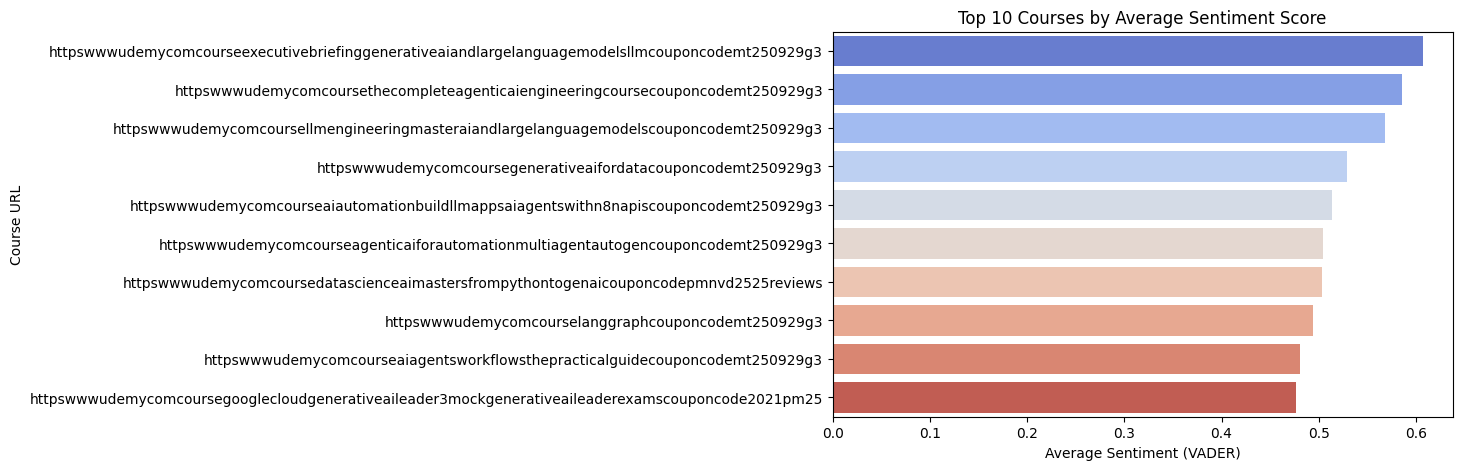

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
# dùng course_url thay vì course_title
avg_sent = df.groupby("course_url")["vader_score"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=avg_sent.values, y=avg_sent.index, palette="coolwarm")
plt.title("Top 10 Courses by Average Sentiment Score")
plt.xlabel("Average Sentiment (VADER)")
plt.ylabel("Course URL")
plt.tight_layout()
plt.show()


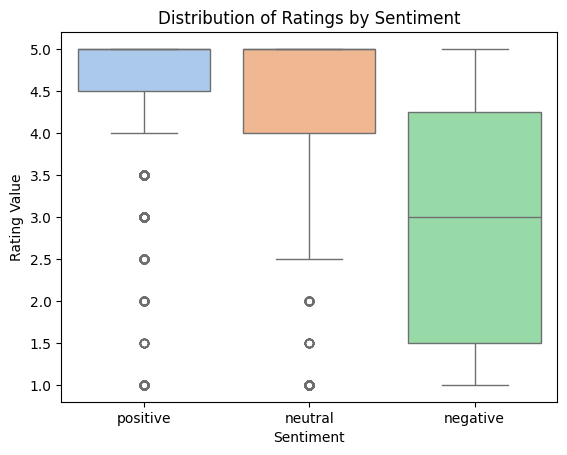

In [61]:
sns.boxplot(x="label", y="rating_value", data=df, palette="pastel")
plt.title("Distribution of Ratings by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Rating Value")
plt.show()


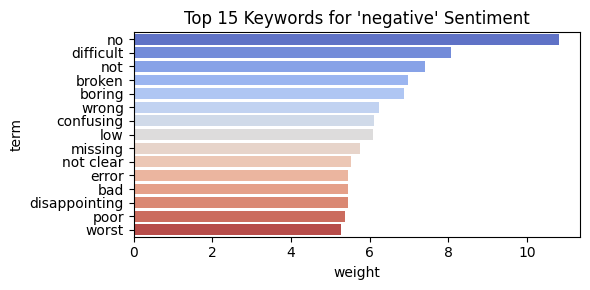

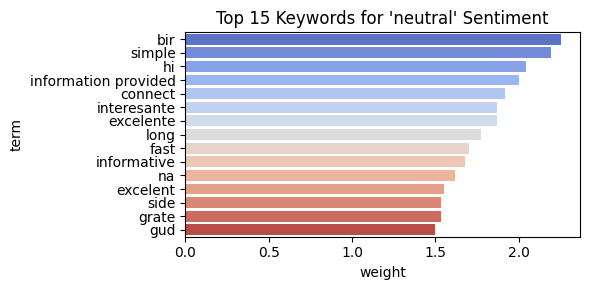

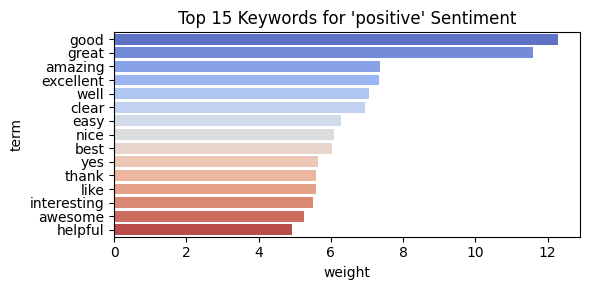

In [64]:
from joblib import load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
clf_best = load("artifacts/logreg_tuned.joblib")
tfidf_best = load("artifacts/tfidf_tuned.joblib")

# Lấy tên feature
features = np.array(tfidf_best.get_feature_names_out())
classes = clf_best.classes_

# Vẽ top từ cho từng lớp
for i, cls in enumerate(classes):
    top_idx = np.argsort(clf_best.coef_[i])[::-1][:15]
    top_feats = pd.DataFrame({
        "term": features[top_idx],
        "weight": clf_best.coef_[i][top_idx]
    })
    plt.figure(figsize=(6,3))
    sns.barplot(x="weight", y="term", data=top_feats, palette="coolwarm")
    plt.title(f"Top 15 Keywords for '{cls}' Sentiment")
    plt.tight_layout()
    plt.show()
